<a href="https://colab.research.google.com/github/tnc1/ai-ml/blob/main/day10_task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
  TASK 3 — STUDENT ENGAGEMENT SEGMENTATION
    (K-Means Clustering)
    The university wants to group students into:
      ● Low Engagement
      ● Medium Engagement
      ● High Engagement
    based on:
      ● LMS Usage Hours
      ● Library Visits
      ● Attendance
  Tasks
    1. Train a K-Means model with 3 clusters.
    2. Predict clusters for students.
    3. Assign cluster labels:
      ○ Low Engagement
      ○ Medium Engagement
      ○ High Engagement
    4. Visualize clusters using Matplotlib.
"""

'\n  TASK 3 — STUDENT ENGAGEMENT SEGMENTATION\n    (K-Means Clustering)\n    The university wants to group students into:\n      ● Low Engagement\n      ● Medium Engagement\n      ● High Engagement\n    based on:\n      ● LMS Usage Hours\n      ● Library Visits\n      ● Attendance\n  Tasks\n    1. Train a K-Means model with 3 clusters.\n    2. Predict clusters for students.\n    3. Assign cluster labels:\n      ○ Low Engagement\n      ○ Medium Engagement\n      ○ High Engagement\n    4. Visualize clusters using Matplotlib.      \n'


Original Dataset

   LMS_Hours  Library_Visits  Attendance
0          1               0          40
1          2               1          50
2          3               1          55
3          5               3          70
4          6               4          75
5          7               5          80
6          9               7          90
7         10               8          95
8         12               9          98

Predicted Clusters

[2 2 2 0 0 0 1 1 1]

Cluster Centers

[[ 6.          4.         75.        ]
 [10.33333333  8.         94.33333333]
 [ 2.          0.66666667 48.33333333]]

Updated Dataset

   LMS_Hours  Library_Visits  Attendance  Predicted  Mapped_Predicted  \
0          1               0          40          2                 0   
1          2               1          50          2                 0   
2          3               1          55          2                 0   
3          5               3          70          0                 1   
4          

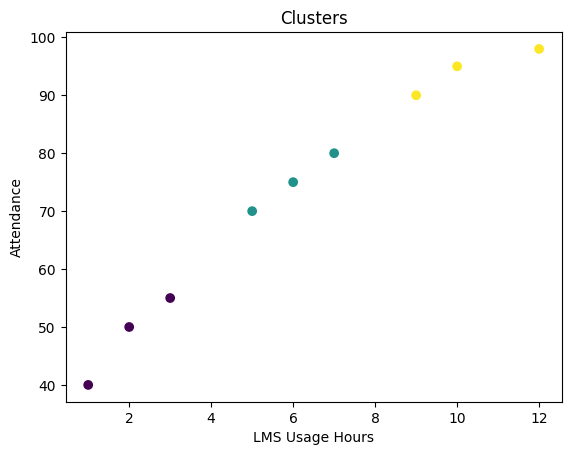

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score
)

# ============================================
# Create Dataset
# ============================================

data = {

    'LMS_Hours':
    [1,2,3,
     5,6,7,
     9,10,12],

    'Library_Visits':
    [0,1,1,
     3,4,5,
     7,8,9],

    'Attendance':
    [40,50,55,
     70,75,80,
     90,95,98]
}

df = pd.DataFrame(data)

print("\nOriginal Dataset\n")

print(df)

# ============================================
# Select Input Features
# ============================================

X = df[
    [
        'LMS_Hours',
        'Library_Visits',
        'Attendance'
    ]
]

# ============================================
# Train K-Means
# ============================================

model = KMeans(
    n_clusters=3,
    random_state=42
)

model.fit(X)


# ============================================
# Predict Clusters
# ============================================

predicted = model.labels_

df['Predicted'] = predicted


print("\nPredicted Clusters\n")

print(predicted)


# ============================================
# IMPORTANT:
# K-Means labels are random
# ============================================

print("\nCluster Centers\n")

print(model.cluster_centers_)


# Actual learned clusters:

# Cluster 2 → Low
# Cluster 0 → Medium
# Cluster 1 → High

cluster_mapping = {

2:0,
0:1,
1:2

}


df['Mapped_Predicted'] = (
    df['Predicted']
    .map(cluster_mapping)
)


# Human-friendly labels

activity_map = {

0:'Low Engagement',
1:'Medium Engagement',
2:'High Engagement'

}


df['Level']=(
    df['Mapped_Predicted']
    .map(activity_map)
)


print("\nUpdated Dataset\n")

print(df)


# ============================================
# Visualization
# ============================================

plt.scatter(

    df['LMS_Hours'],
    df['Attendance'],

    c=df['Mapped_Predicted']

)

plt.xlabel("LMS Usage Hours")
plt.ylabel("Attendance")

plt.title(
    "Clusters"
)

plt.show()